# Chapter 6: Bayesian formalized

PyMC sampling lives in `generate.py` and is reloaded from disk here. The cells below run the closed-form Beta math live so the notebook executes in seconds.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta as beta_dist
from expkit.sim.coin import bernoulli_sequence
from expkit.inference.bayes import bayes_factor_point_vs_uniform, conjugate_posterior_predictive
from expkit.io.samples import load_idata
from expkit.plot.style import apply_style, PALETTE
apply_style()

## Loop B: priors that argue

Tune the prior; watch the posterior shift. With small N the prior is loud; with large N the data drowns it.

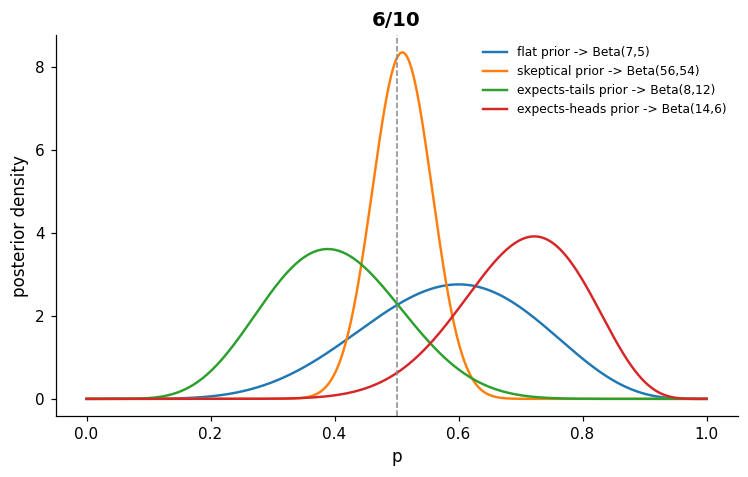

In [2]:
def show_posterior(k, n, priors=None):
    if priors is None:
        priors = [('flat', 1, 1), ('skeptical', 50, 50), ('expects-tails', 2, 8), ('expects-heads', 8, 2)]
    ps = np.linspace(0, 1, 1000)
    fig, ax = plt.subplots()
    for name, a0, b0 in priors:
        a, b = a0 + k, b0 + (n - k)
        ax.plot(ps, beta_dist.pdf(ps, a, b), label=f'{name} prior -> Beta({a},{b})')
    ax.axvline(0.5, color=PALETTE['muted'], linestyle='--', linewidth=1)
    ax.set_xlabel('p'); ax.set_ylabel('posterior density'); ax.set_title(f'{k}/{n}'); ax.legend(fontsize=8)
    plt.show()
show_posterior(6, 10)

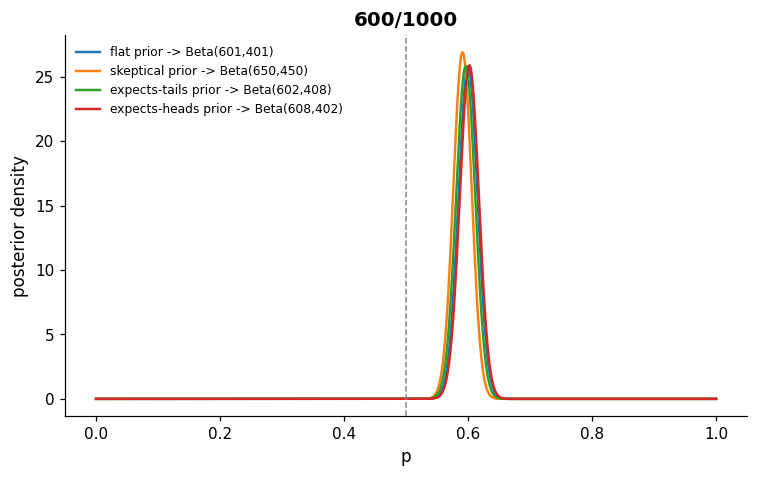

In [3]:
show_posterior(600, 1000)  # at large N every prior collapses to the same place

## Reload the PyMC posterior from disk

`generate.py` already ran `pm.sample` and saved the trace. We just read it.

PyMC posterior: mean=0.5441  95% CI=[0.4757, 0.6115]


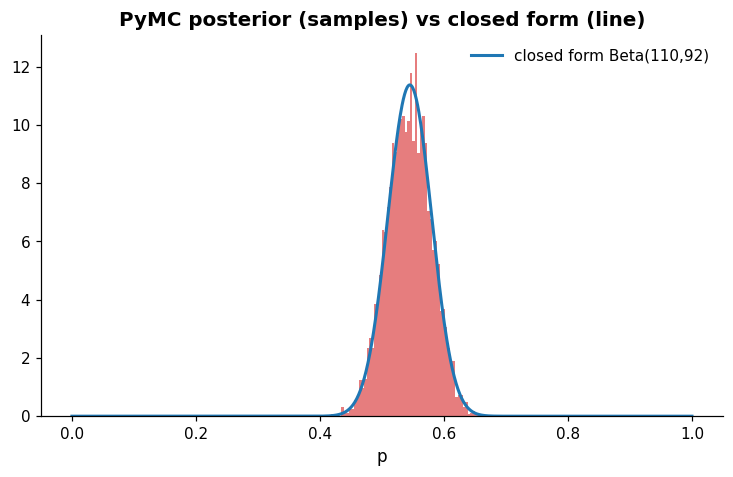

In [4]:
from pathlib import Path
trace_path = Path('chapters/06-bayesian/data/posterior_chapter6.nc')
if not trace_path.exists():
    trace_path = Path('data/posterior_chapter6.nc')  # if running from chapter dir
if trace_path.exists():
    idata = load_idata(trace_path)
    p = idata.posterior['p'].values.ravel()
    print(f'PyMC posterior: mean={p.mean():.4f}  95% CI=[{np.quantile(p, 0.025):.4f}, {np.quantile(p, 0.975):.4f}]')
    fig, ax = plt.subplots()
    ax.hist(p, bins=60, density=True, color=PALETTE['bayesian'], alpha=0.6)
    a_cf, b_cf = idata.attrs.get('heads', 0) + idata.attrs.get('prior_alpha', 1), (idata.attrs.get('n', 1) - idata.attrs.get('heads', 0)) + idata.attrs.get('prior_beta', 1)
    ps = np.linspace(0, 1, 1000)
    ax.plot(ps, beta_dist.pdf(ps, a_cf, b_cf), color=PALETTE['frequentist'], linewidth=2, label=f'closed form Beta({a_cf:.0f},{b_cf:.0f})')
    ax.set_xlabel('p'); ax.set_title('PyMC posterior (samples) vs closed form (line)'); ax.legend()
    plt.show()
else:
    print('Run generate.py first to produce the trace.')

## Loop D: Bayes factor accumulates evidence

The data is a slightly biased coin (p=0.55). BF_10 is the ratio of marginal likelihoods (uniform alternative vs point H0 of fair). It rises slowly at small N, then takes off.

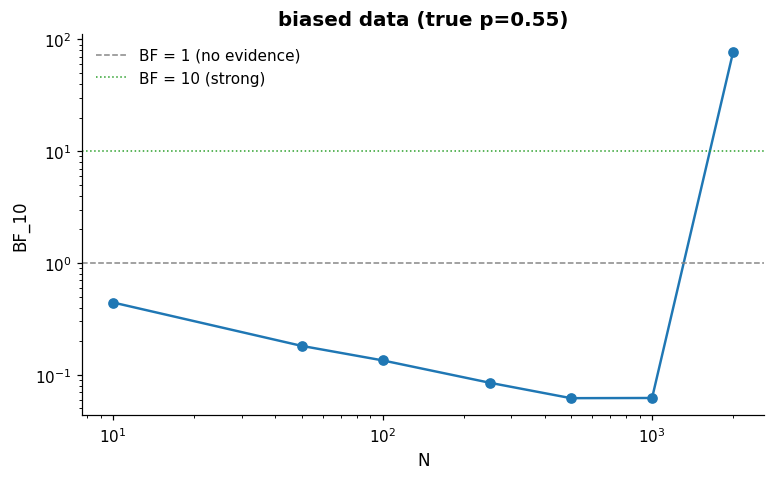

N=   10: BF_10 = 0.443
N=   50: BF_10 = 0.182
N=  100: BF_10 = 0.135
N=  250: BF_10 = 0.0849
N=  500: BF_10 = 0.0618
N= 1000: BF_10 = 0.0621
N= 2000: BF_10 = 77.7


In [5]:
rng = np.random.default_rng(0)
biased = rng.binomial(1, 0.55, size=2000)
ns = [10, 50, 100, 250, 500, 1000, 2000]
bfs = [bayes_factor_point_vs_uniform(biased[:n], point=0.5) for n in ns]
fig, ax = plt.subplots()
ax.plot(ns, bfs, marker='o')
ax.axhline(1, color=PALETTE['muted'], linestyle='--', linewidth=1, label='BF = 1 (no evidence)')
ax.axhline(10, color=PALETTE['highlight'], linestyle=':', linewidth=1, label='BF = 10 (strong)')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('N'); ax.set_ylabel('BF_10'); ax.set_title('biased data (true p=0.55)'); ax.legend()
plt.show()
for n, bf in zip(ns, bfs):
    print(f'N={n:>5}: BF_10 = {bf:.3g}')

## Loop E: posterior predictive

The reader has observed 50 tosses (true p ~ 0.6). What's the predicted heads count in the next 20 tosses? The posterior predictive marginalizes over uncertainty in p.

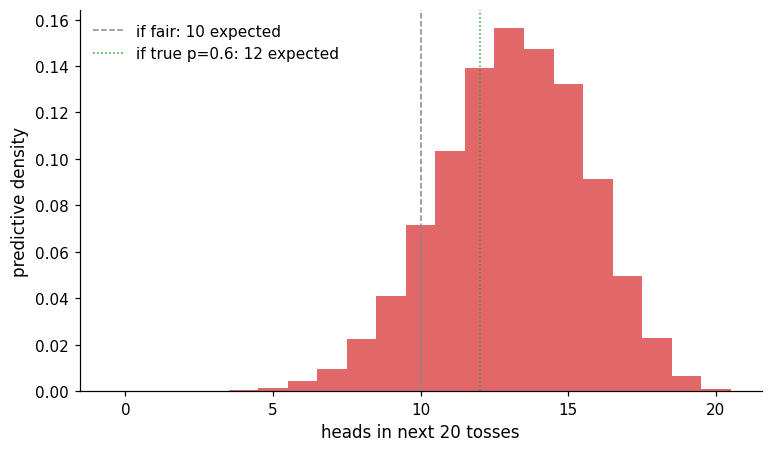

  quantile 0.025: 8.0
  quantile 0.25: 11.0
  quantile 0.5: 13.0
  quantile 0.75: 15.0
  quantile 0.975: 18.0


In [6]:
seq = bernoulli_sequence(50, p=0.6, seed=11)
preds = conjugate_posterior_predictive(seq, new_n=20, n_samples=10000, seed=0)
fig, ax = plt.subplots()
bins = np.arange(-0.5, 21.5, 1.0)
ax.hist(preds, bins=bins, density=True, color=PALETTE['bayesian'], alpha=0.7)
ax.axvline(10, color=PALETTE['muted'], linestyle='--', linewidth=1, label='if fair: 10 expected')
ax.axvline(12, color=PALETTE['highlight'], linestyle=':', linewidth=1, label='if true p=0.6: 12 expected')
ax.set_xlabel('heads in next 20 tosses'); ax.set_ylabel('predictive density'); ax.legend(); plt.show()
for q in [0.025, 0.25, 0.5, 0.75, 0.975]:
    print(f'  quantile {q}: {np.quantile(preds, q):.1f}')